In [3]:
import pandas as pd

df = pd.read_csv("c:/data/test/customer_dbscan.csv")
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   visit_count   115 non-null    float64
 1   avg_spending  115 non-null    float64
 2   stay_time     115 non-null    float64
dtypes: float64(3)
memory usage: 2.8 KB
None


In [2]:
print(df.head())

   visit_count  avg_spending  stay_time
0    31.490142     49.308678  42.590754
1    34.569090     48.829233  39.063452
2    34.737638     53.837174  38.122102
3    31.627680     47.682912  38.137081
4    30.725887     40.433599  33.100329


In [4]:
#####
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [5]:
#####
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
df["cluster"] = dbscan.fit_predict(X_scaled)

print(df["cluster"].value_counts())

cluster
 0    40
 1    36
 2    30
-1     9
Name: count, dtype: int64


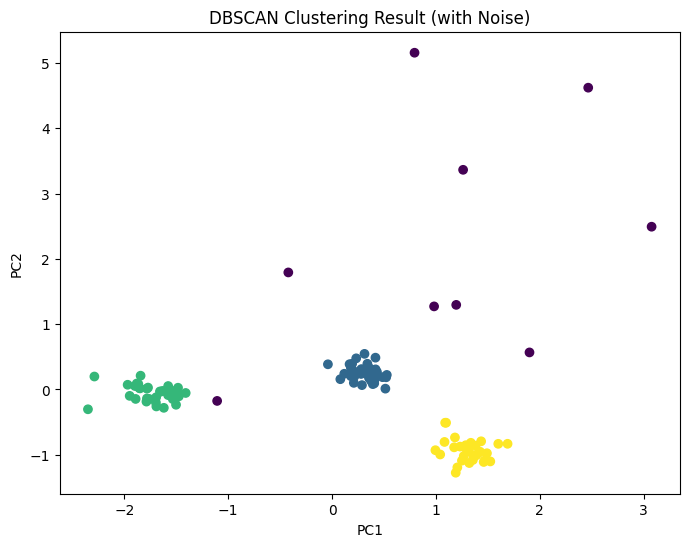

In [6]:
#####
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
#변수 3개 -> 주성분 2개로 변환
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df["pc1"] = X_pca[:, 0]
df["pc2"] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
plt.scatter(df["pc1"], df["pc2"], c=df["cluster"])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Clustering Result (with Noise)")
plt.show()

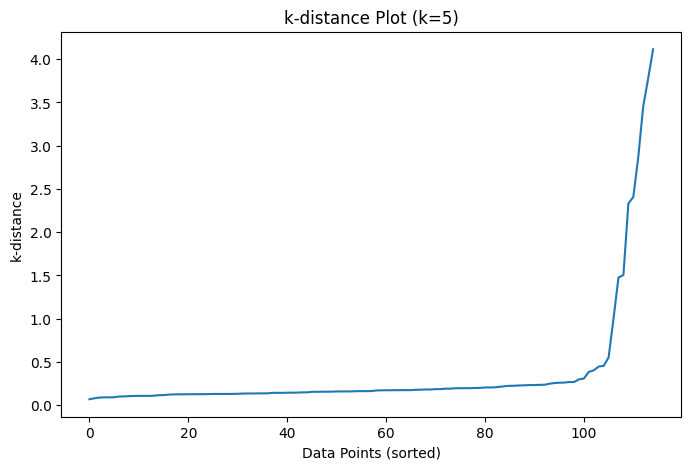

In [7]:
#####
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

k = 5

neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_scaled)
#거리, 샘플의인덱스 리턴
distances, indices = neighbors_fit.kneighbors(X_scaled)

# k번째 이웃 거리만 추출
k_distances = distances[:, k-1]
k_distances = np.sort(k_distances)

plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.xlabel("Data Points (sorted)")
plt.ylabel("k-distance")
plt.title("k-distance Plot (k=5)")
plt.show()
#기울기가 급격하게 증가하기 직전의 값




